In [1]:
# import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import the data and view the first few rows
df = pd.read_csv("food_menu_nutrition_dataset.csv")
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
price_usd_normalized,8.66,2.78,5.77,8.47,2.79
serving_size_g,224.9,151.7,294.1,87.7,125.4


In [3]:
# Display the shape of the dataframe
shape_df = pd.DataFrame(
    df.shape,
    index=["Rows", "Columns"],
    columns=["Count"],
)
display(shape_df)

# Display count by data type
dtype_df = df.dtypes.value_counts().to_frame(name="Number of Columns")
dtype_df.index.name = "Data Type"
display(dtype_df.reset_index())

,Count
Rows,7500
Columns,18


,Data Type,Number of Columns
0,float64,9
1,str,8
2,int64,1


In [4]:
# Calculate descriptive statistics including skewness and kurtosis
stats = df.describe().T
stats['skew'] = df.select_dtypes(include=[np.number]).skew()
stats['kurtosis'] = df.select_dtypes(include=[np.number]).kurtosis()

display(stats[['mean', '50%', 'std', 'min',
        'max', 'skew', 'kurtosis']].round(2))

,mean,50%,std,min,max,skew,kurtosis
price_usd_normalized,8.49,5.72,8.54,0.63,66.58,2.64,8.82
serving_size_g,249.69,220.50,121.12,50.00,760.20,0.87,0.22
calories,359.16,347.40,175.30,5.00,934.30,0.21,-0.38
protein_g,11.97,9.70,10.10,0.00,45.00,0.70,-0.47
total_fat_g,13.93,13.00,9.93,0.00,61.10,0.66,0.10
total_carbs_g,44.96,44.00,18.52,0.00,127.20,0.25,0.05
sodium_mg,511.34,533.50,345.80,0.00,1672.00,0.14,-0.99
sugars_g,14.62,8.20,14.96,0.00,82.40,1.49,1.15
avg_rating,3.82,3.90,0.59,1.60,5.00,-0.52,-0.15
is_bestseller,0.16,0.00,0.37,0.00,1.00,1.86,1.48


In [5]:
cat_stats = df.describe(include='str').T

display(cat_stats[['unique', 'top', 'freq']])

,unique,top,freq
item_name,114,Double Smash Burger,137
item_category,8,Drink,1505
item_subcategory,3,Veg,3611
brand_name,18,Subway,586
brand_tier,3,budget,4415
country,5,USA,2721
city,53,Houston,334
city_tier,3,metro,3350


In [6]:
# Display column number, column name, non-null count, and data type
df.isnull().sum()

item_name               0
item_category           0
item_subcategory        0
brand_name              0
brand_tier              0
country                 0
city                    0
city_tier               0
price_usd_normalized    0
serving_size_g          0
calories                0
protein_g               0
total_fat_g             0
total_carbs_g           0
sodium_mg               0
sugars_g                0
avg_rating              0
is_bestseller           0
dtype: int64

No missing data is present in the data set, so no imputation is necessary

In [7]:
# check for duplicates
duplicates = df[df.duplicated()]
duplicates.shape[0]

0

No duplicate data is present in the data set, so not records need to be dropped.

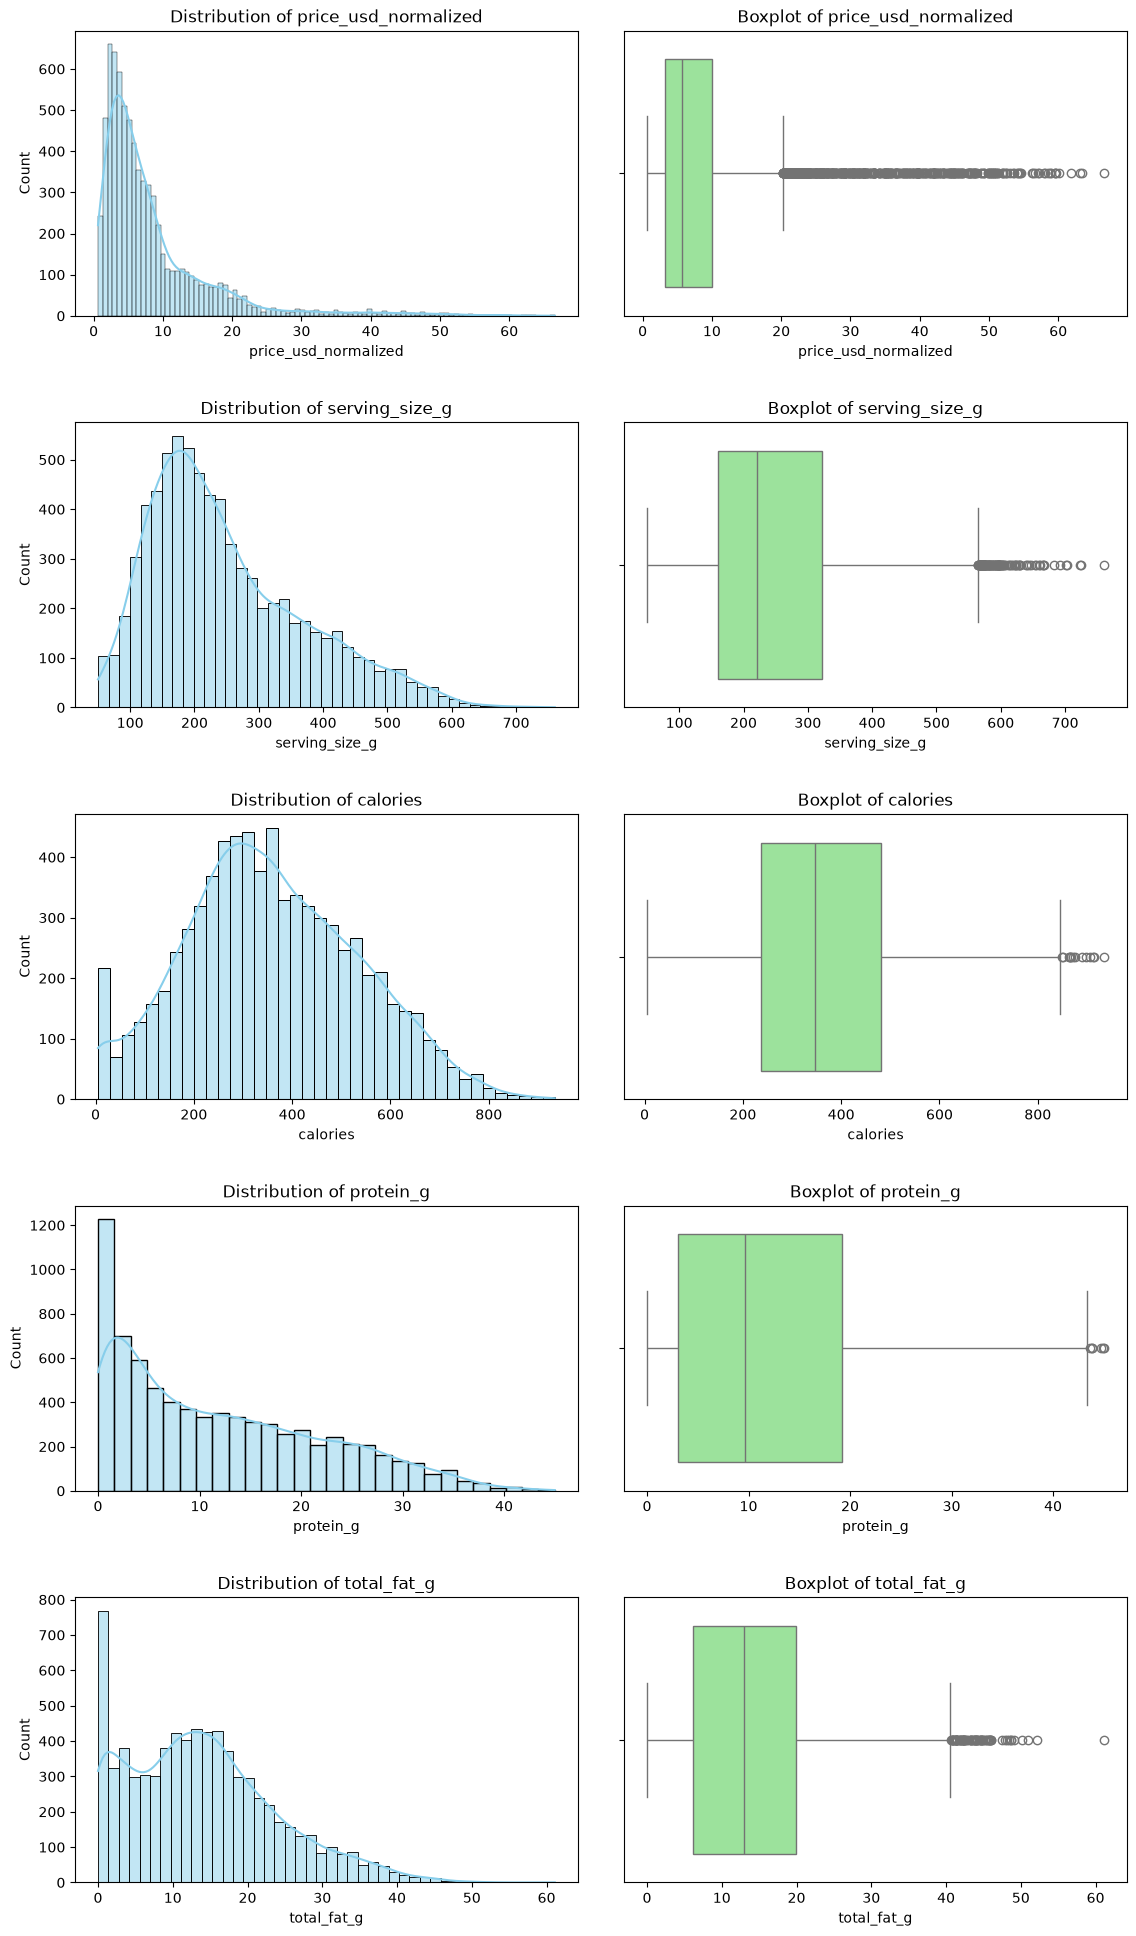

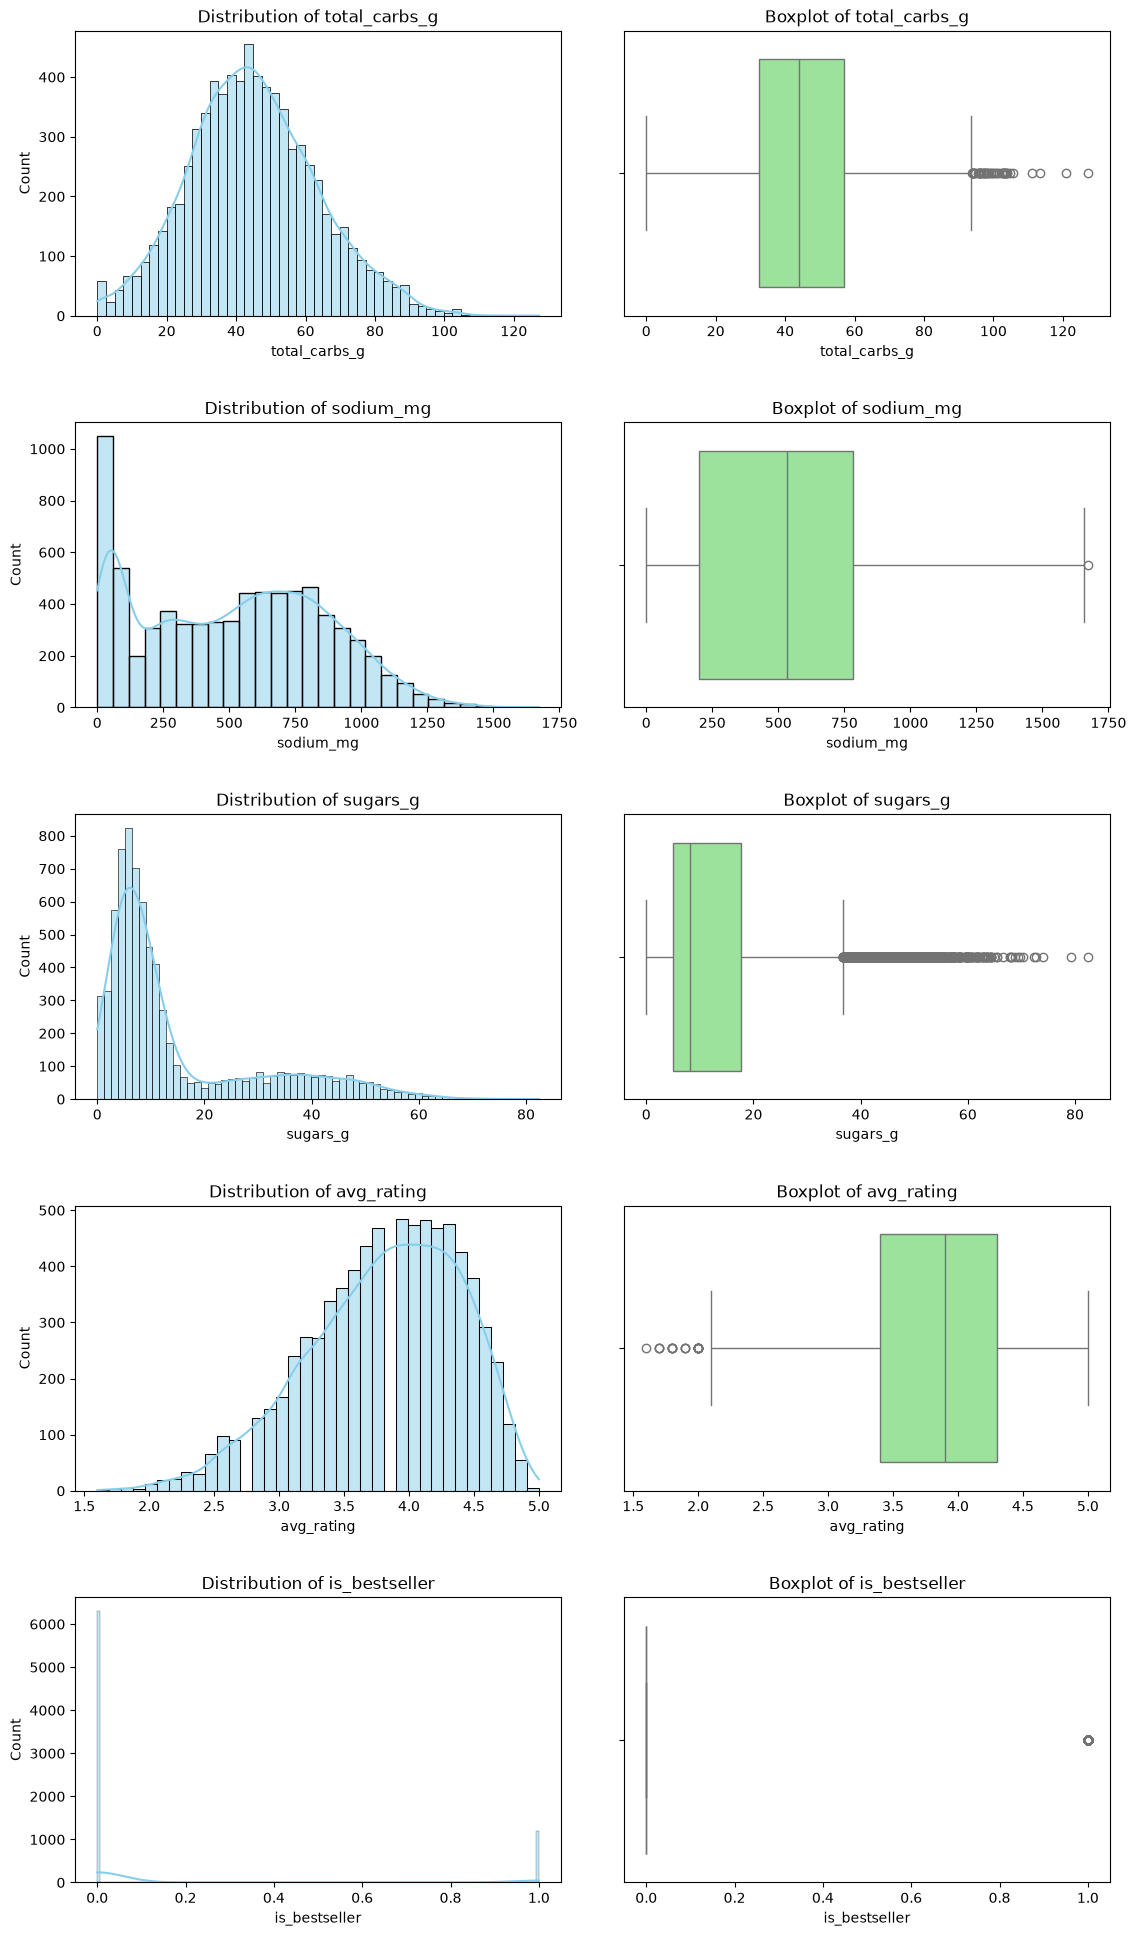

In [8]:
# Plot distribution and boxplots for all numeric variables

cols = df.select_dtypes(include=['number']).columns
n_cols = 2
vars_per_fig = 5

# Loop through variables in chunks
for i in range(0, len(cols), vars_per_fig):
    chunk = cols[i:i + vars_per_fig]

    fig, axes = plt.subplots(len(chunk),
                             n_cols, figsize=(12, 4 * len(chunk)))

    for idx, col in enumerate(chunk):

        sns.histplot(df[col], kde=True, ax=axes[idx, 0], color='skyblue')
        axes[idx, 0].set_title(f'Distribution of {col}', fontsize=12)

        sns.boxplot(x=df[col], ax=axes[idx, 1], color='lightgreen')
        axes[idx, 1].set_title(f'Boxplot of {col}', fontsize=12)

    plt.tight_layout(pad=3.0)
    plt.show()

Despite the presence of outliers, decisions trees are robust to outliers as long as the depth and minimum samples per leaf are controlled, so outliers will not be removed. All values fall within expected ranges.

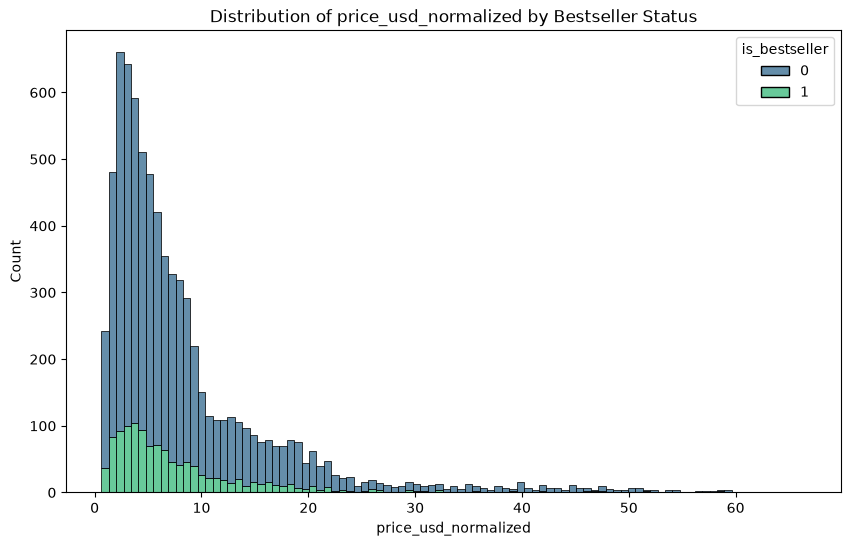

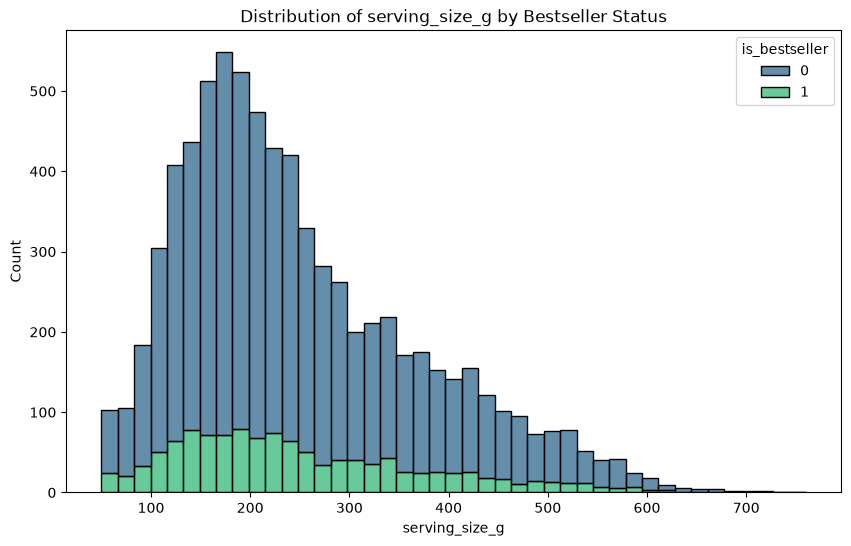

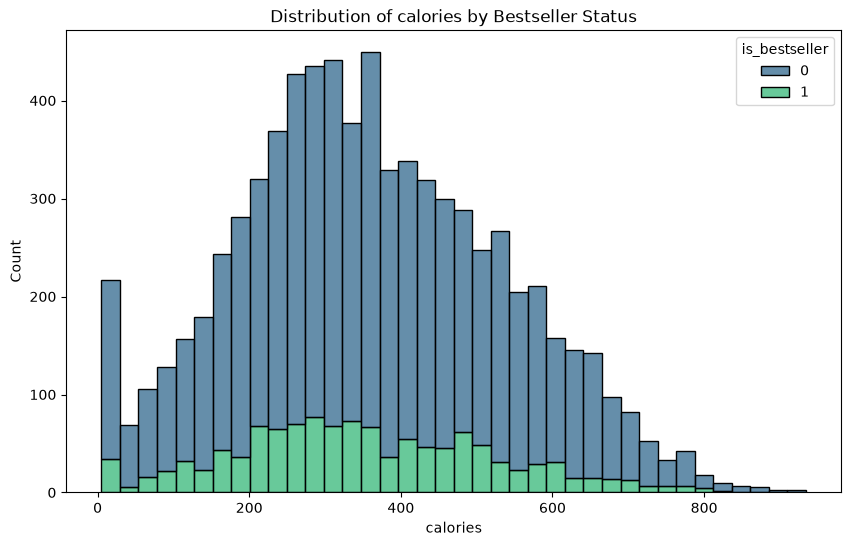

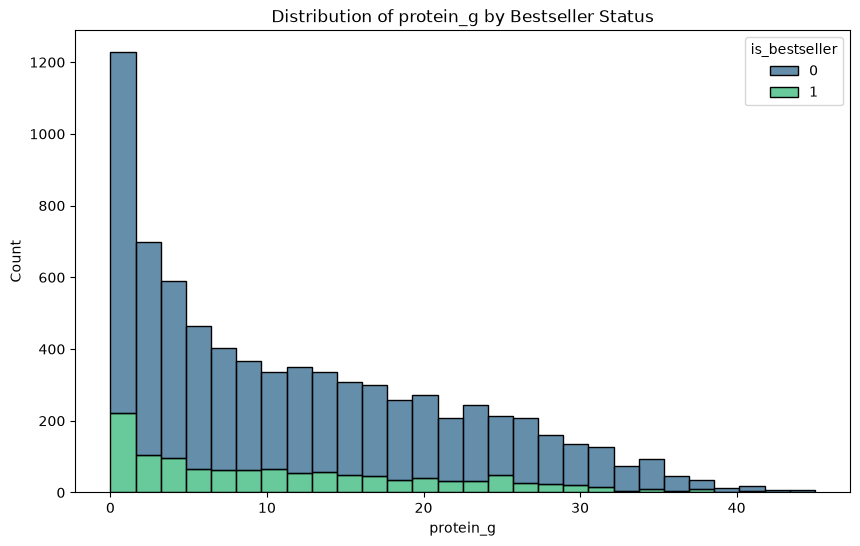

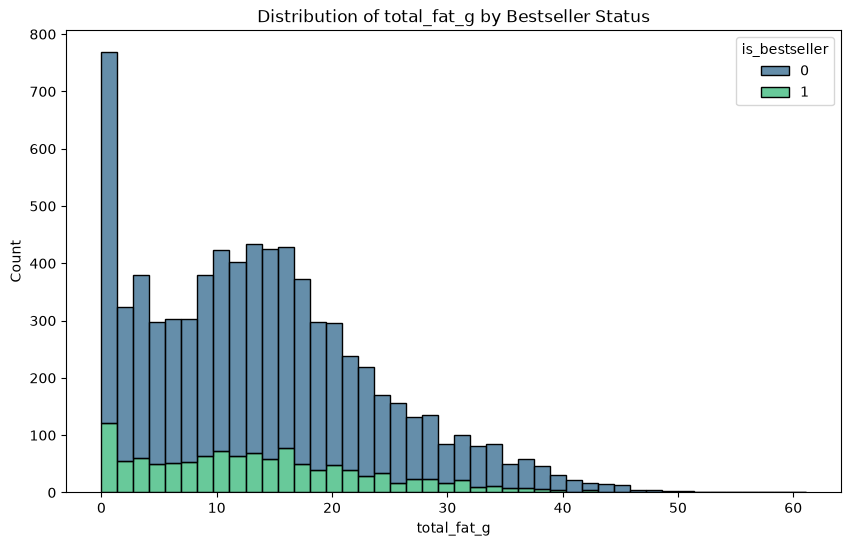

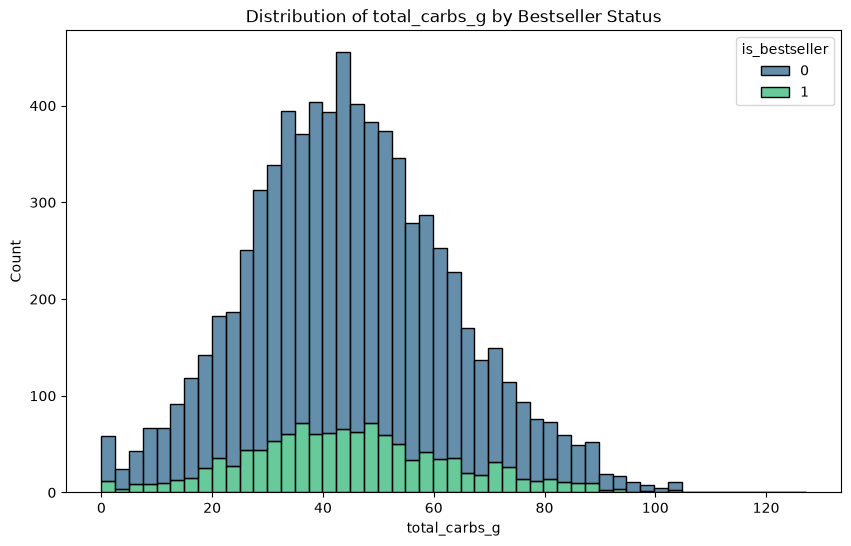

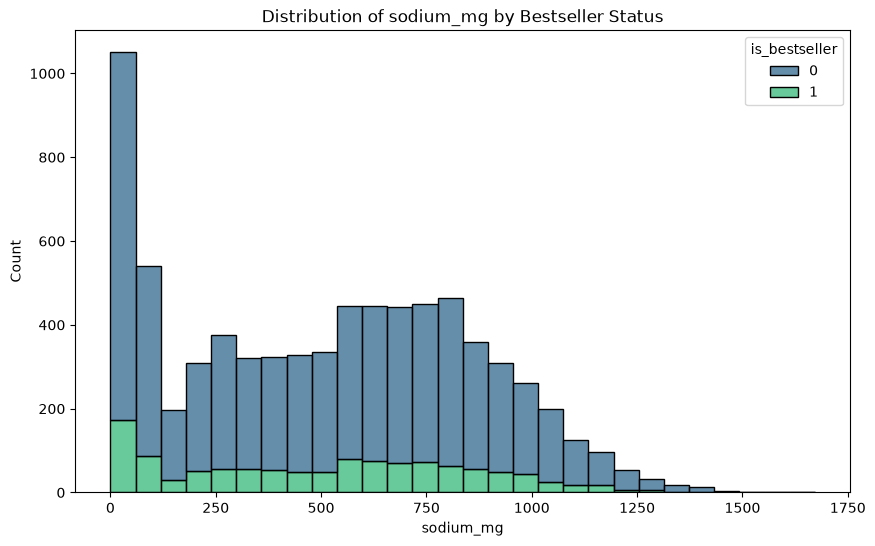

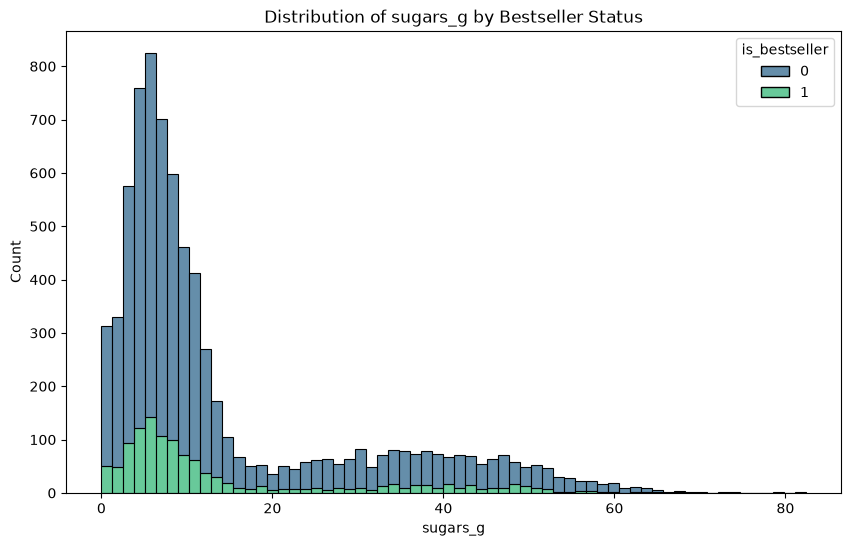

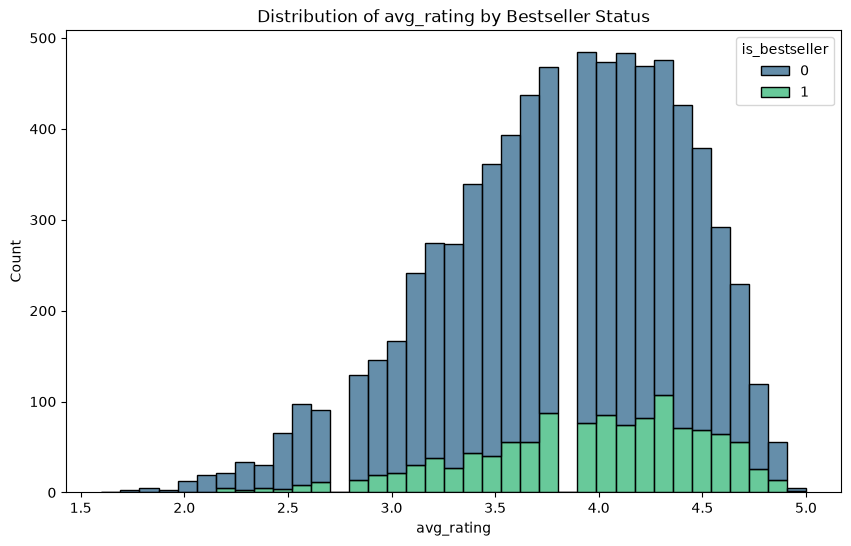

In [9]:
# Plot joint plots for all variables and is_bestseller
features_to_plot = df.select_dtypes(
    include=["number"]).columns.drop("is_bestseller")

for feature in features_to_plot:
    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x=feature,
        hue="is_bestseller",
        multiple="stack",
        palette="viridis"
    )

    plt.title(f"Distribution of {feature} by Bestseller Status")
    plt.show()

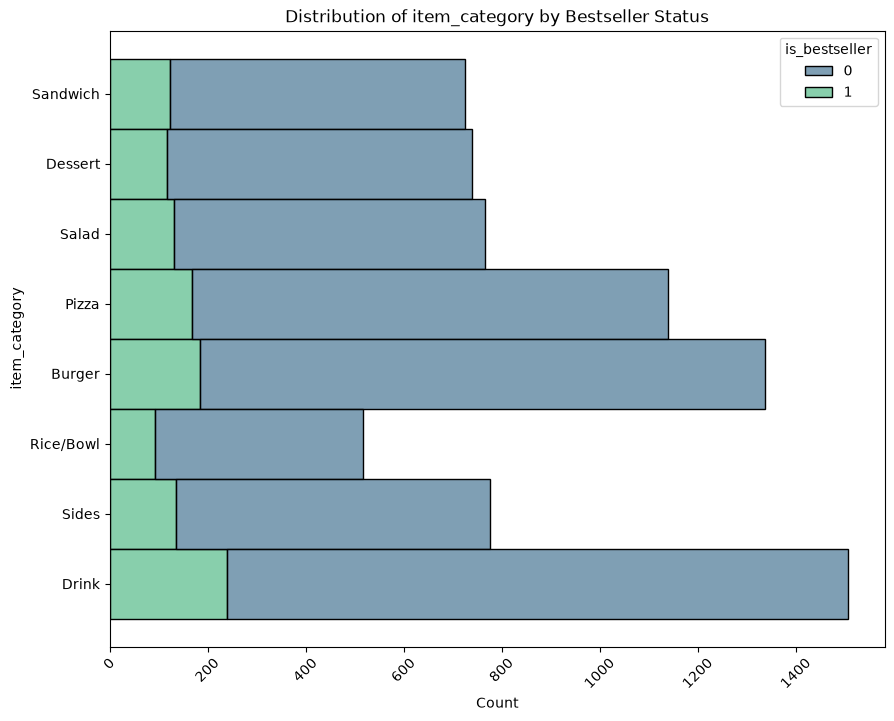

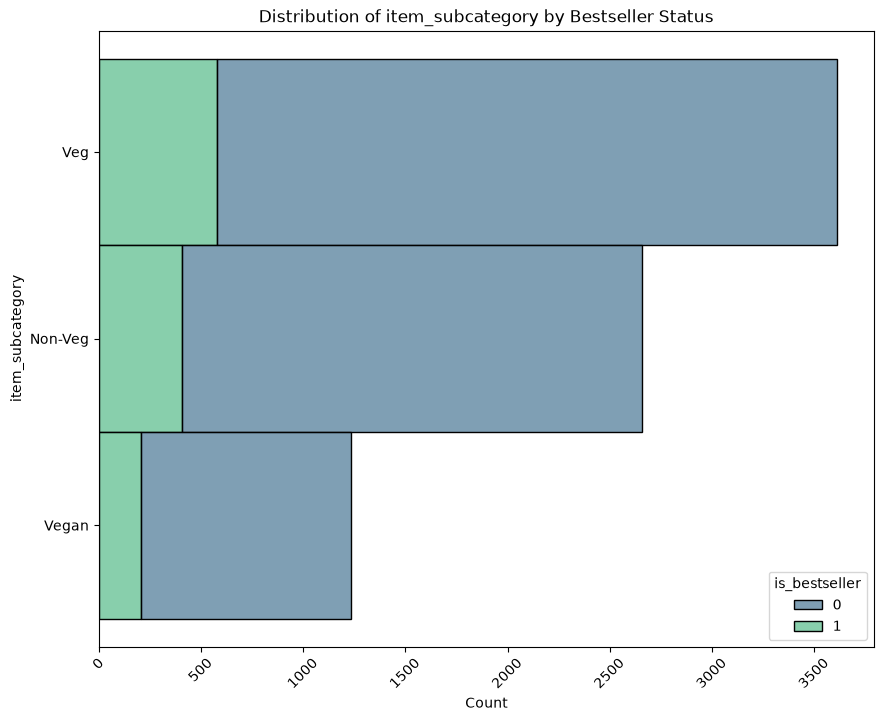

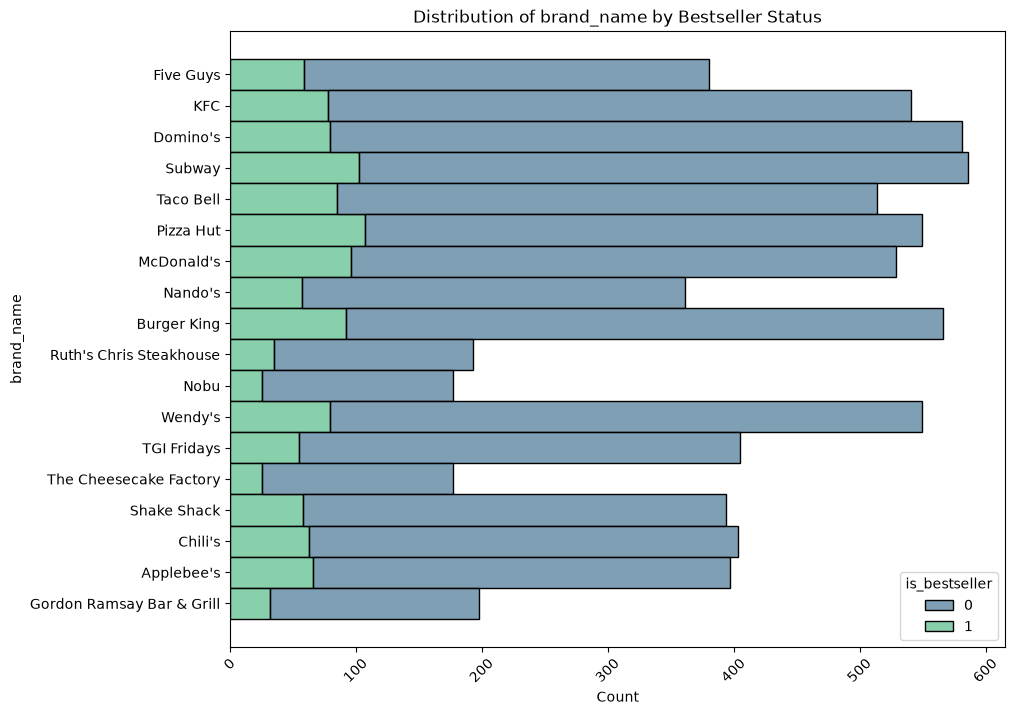

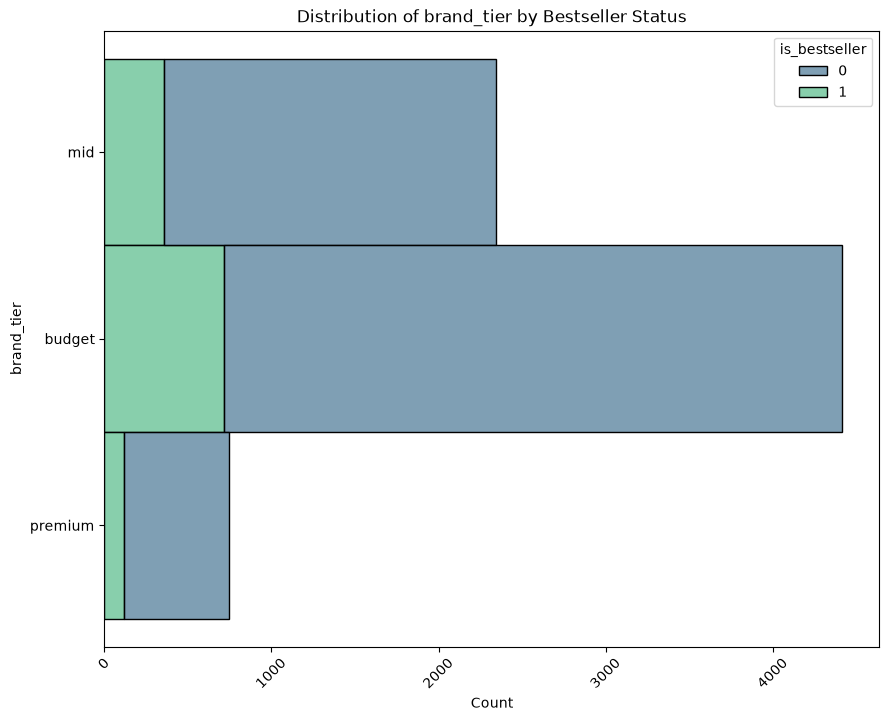

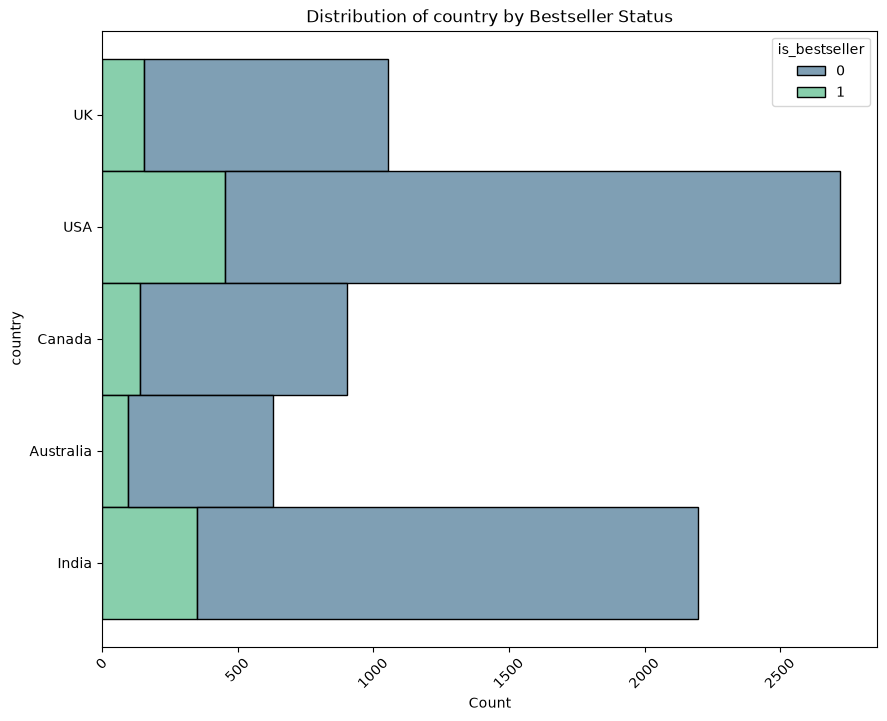

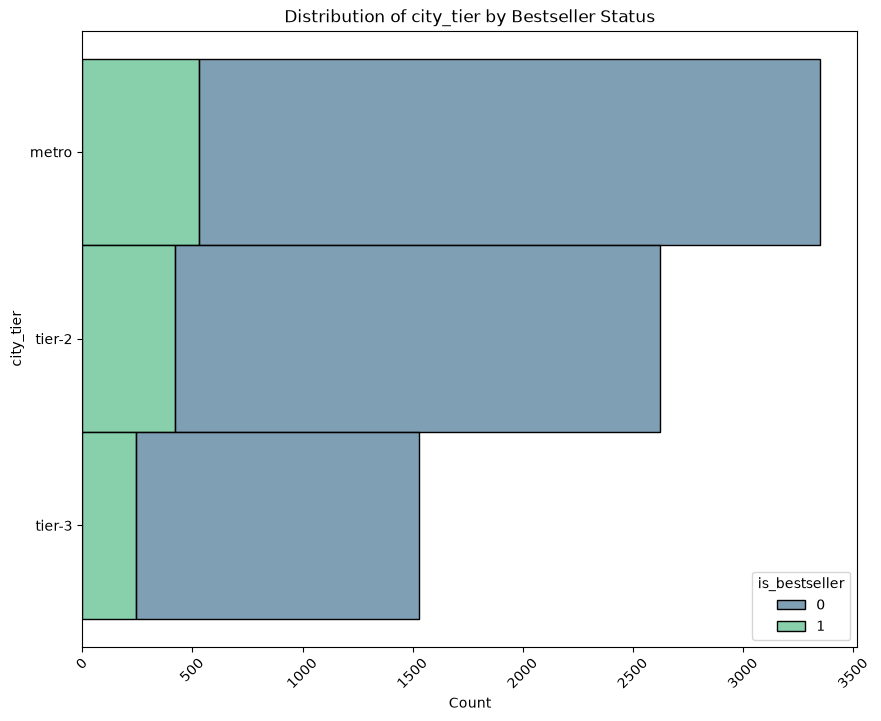

In [10]:
categorical_features = cat_stats.index.drop(["item_name", 'city']).tolist()

for feature in categorical_features:
    plt.figure(figsize=(10, 8))

    sns.histplot(
        data=df,
        y=feature,
        hue="is_bestseller",
        multiple="stack",
        palette=['#547f9b', '#60c090'],
        discrete=True
    )

    plt.title(f"Distribution of {feature} by Bestseller Status")
    plt.xticks(rotation=45)
    plt.show()

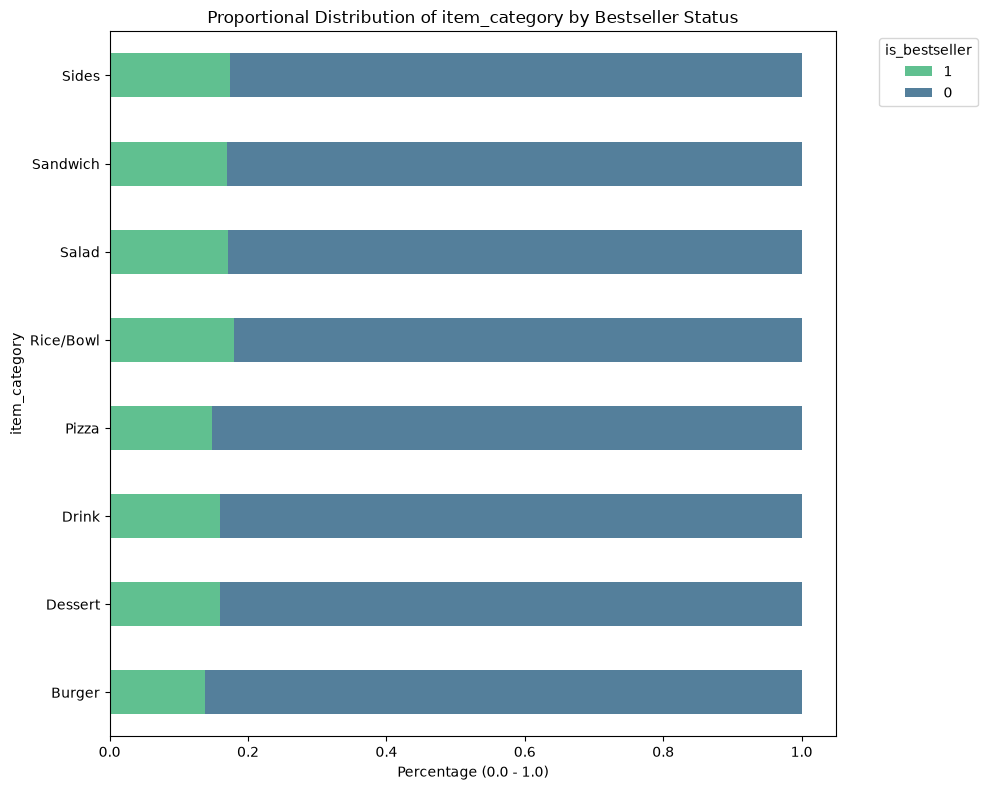

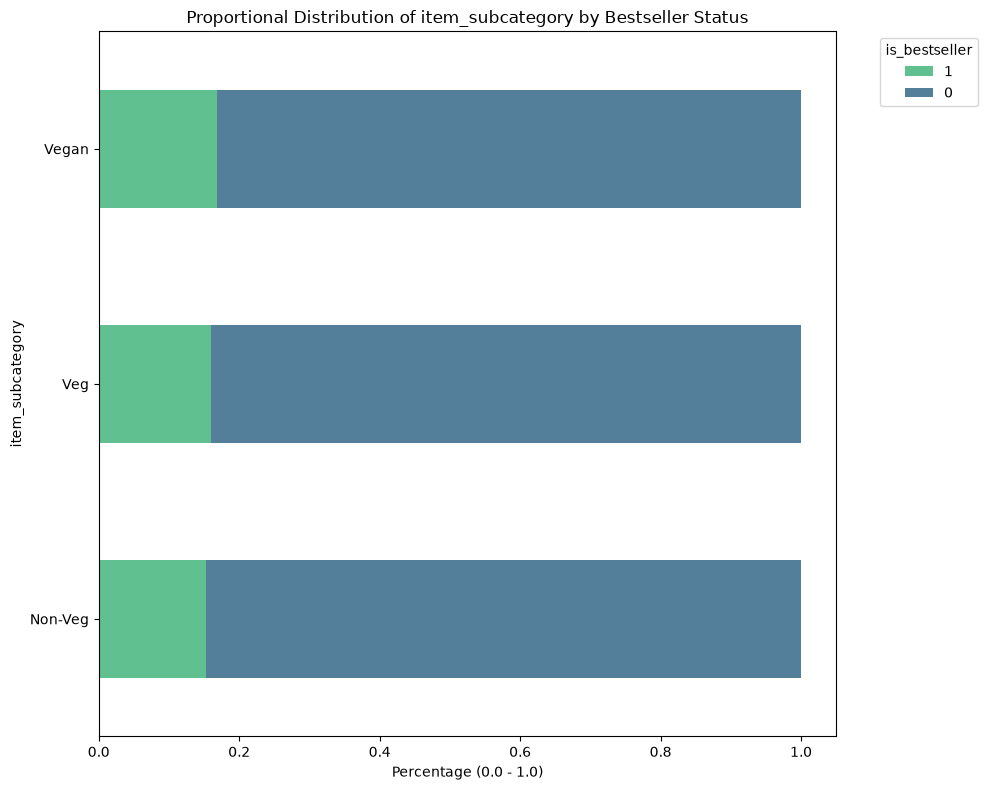

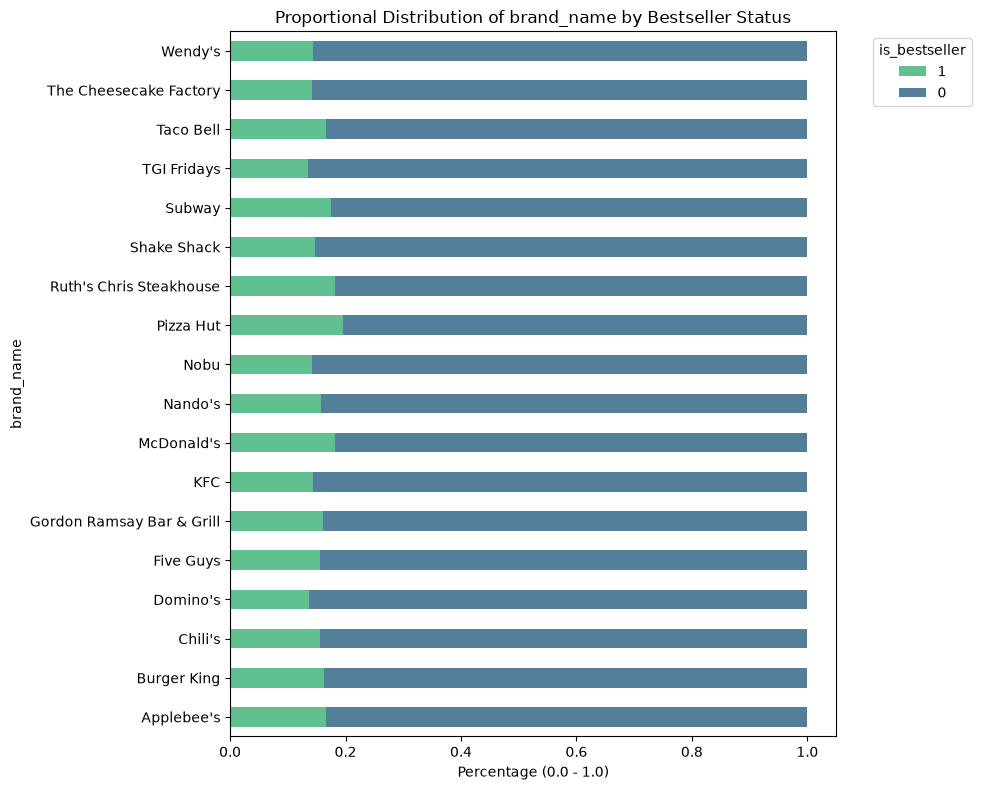

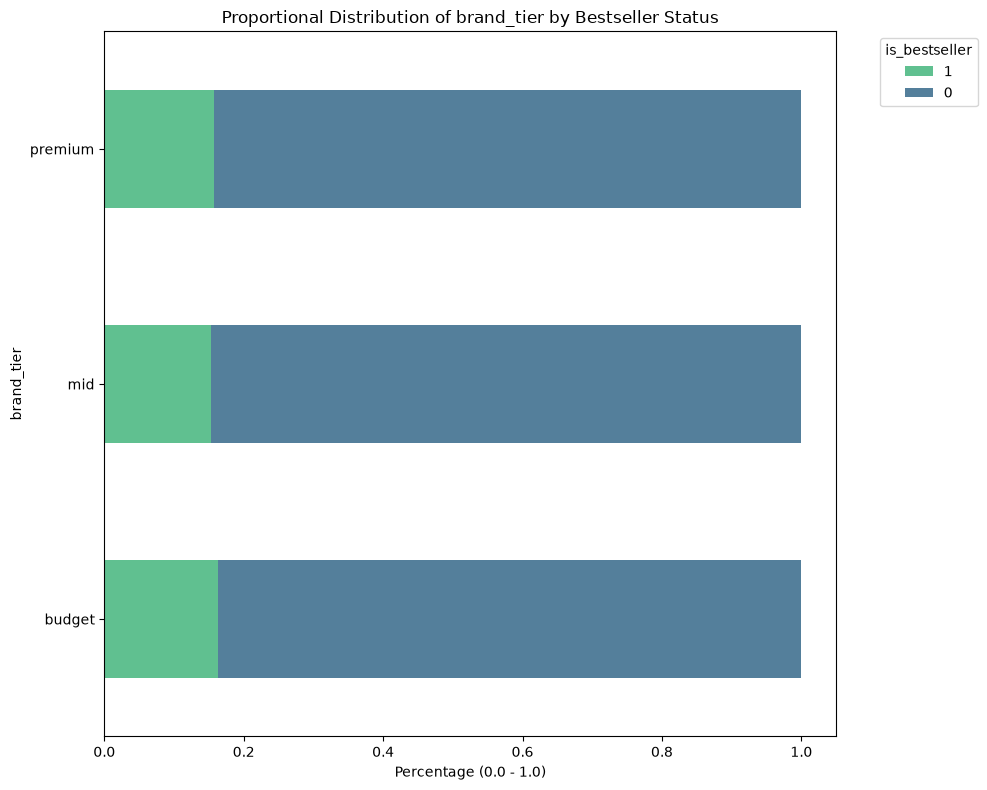

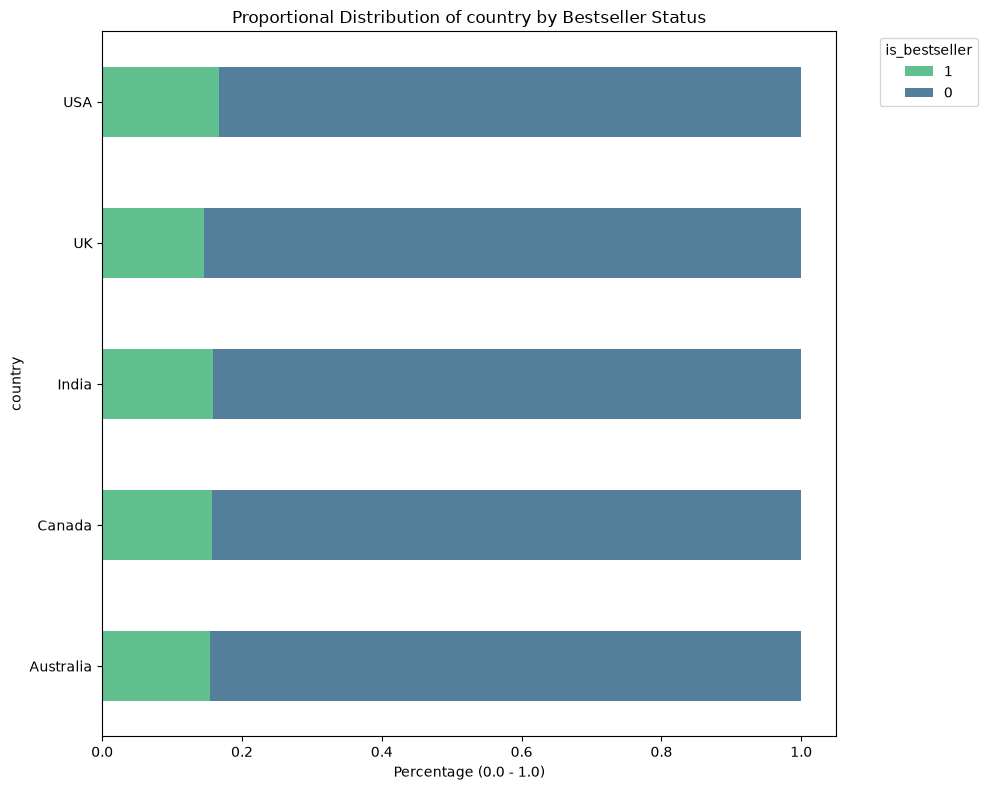

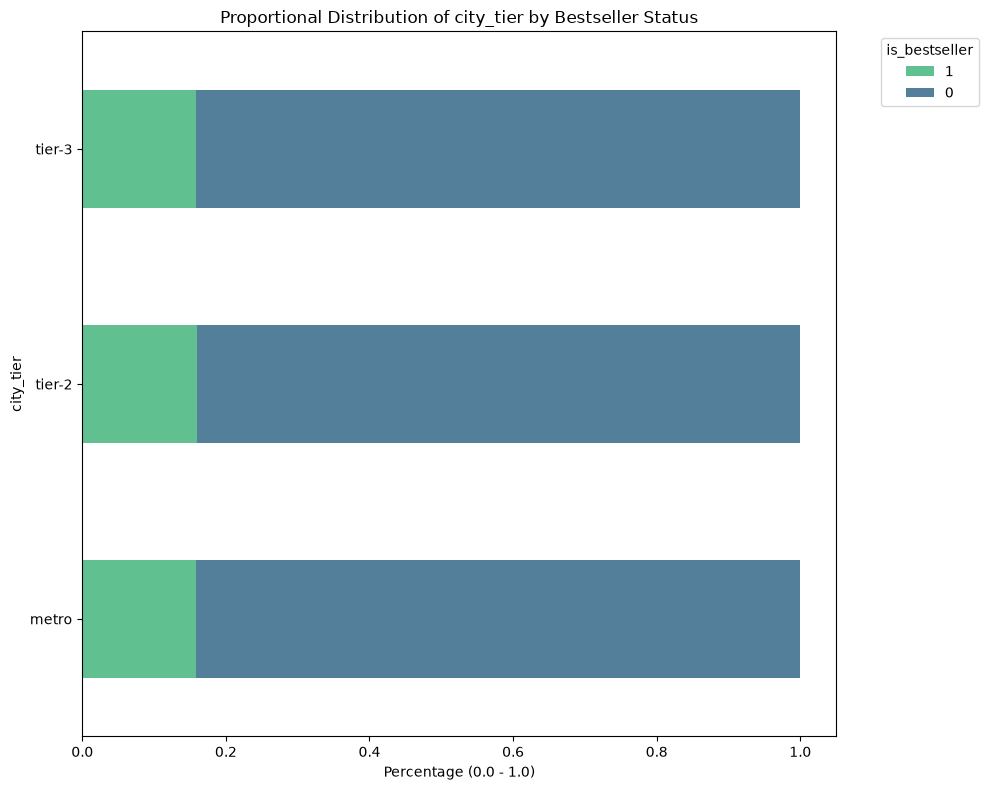

In [11]:
for feature in categorical_features:
    crosstab = pd.crosstab(df[feature], df["is_bestseller"])

    crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)

    crosstab_norm = crosstab_norm[[1, 0]]

    crosstab_norm.plot(kind='barh', stacked=True,
                       figsize=(10, 8),
                       color=['#60c090', '#547f9b'])

    plt.title(f"Proportional Distribution of {feature} by Bestseller Status")
    plt.xlabel("Percentage (0.0 - 1.0)")
    plt.ylabel(feature)

    plt.legend(title="is_bestseller", bbox_to_anchor=(
        1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

Despite some classes within categorical variables having higher total counts, the bestseller flag is relatively evenly distributed among categorical variable classes, indicating that many factors together determine if an item is a bestseller.

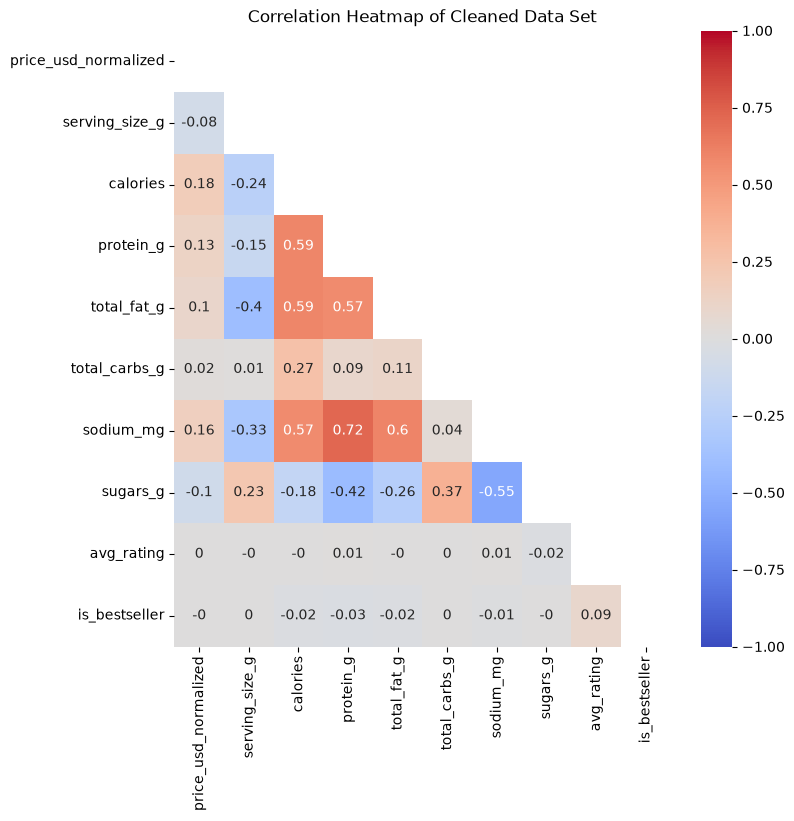

In [12]:
# plot total correlation matrix
corr_matrix = df.corr(numeric_only=True).round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=mask,
)
plt.title("Correlation Heatmap of Cleaned Data Set")
plt.show()

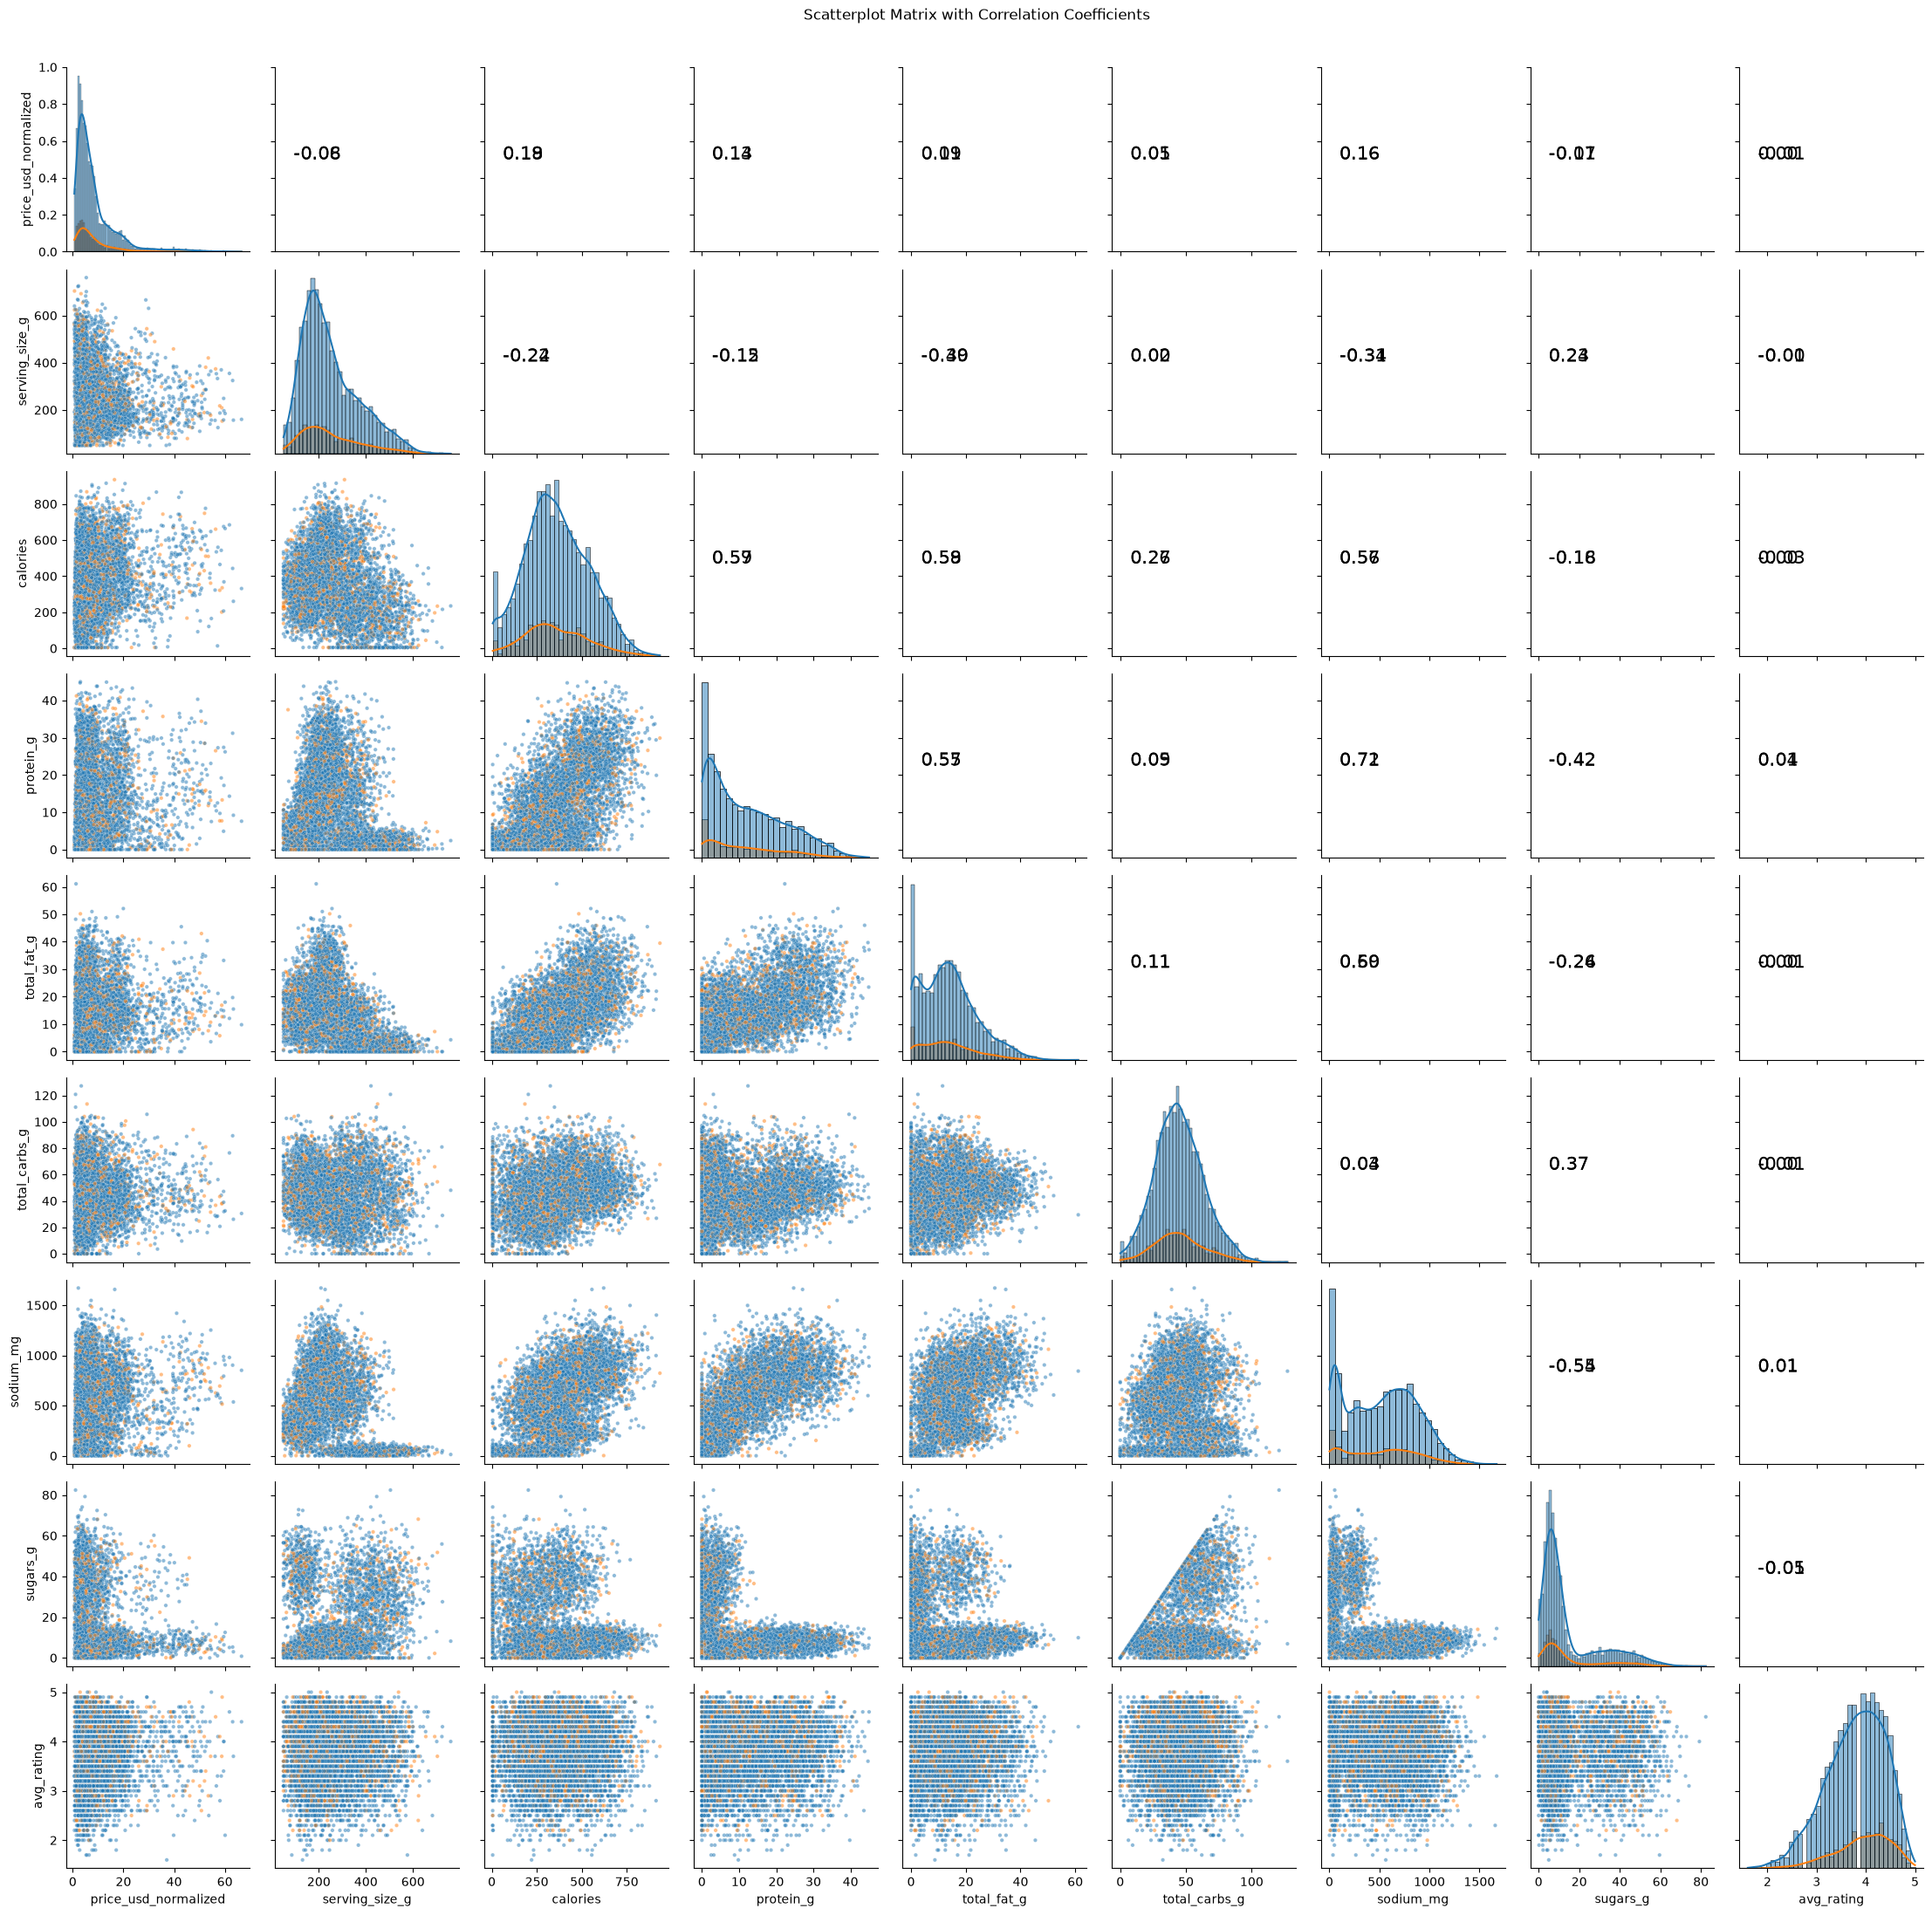

In [13]:
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"{r:.2f}", xy=(.1, .5), xycoords=ax.transAxes, size=15)


numeric_df = df.select_dtypes(include=['number'])

g = sns.PairGrid(numeric_df, hue="is_bestseller", diag_sharey=False)

g.map_lower(sns.scatterplot, s=10, alpha=0.5)

g.map_upper(corrfunc)

g.map_diag(sns.histplot, kde=True)

plt.subplots_adjust(top=0.95)
g.fig.suptitle("Scatterplot Matrix with Correlation Coefficients")
plt.show()